# 2024 SHED Survey - Hispanic Respondents Analysis

Survey of Household Economics and Decisionmaking - Federal Reserve

**Focus:** Hispanic/Latino respondents (n=1,685)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# Load Hispanic respondents dataset
df = pd.read_csv('data_hispanic.csv')

print(f"Hispanic Dataset loaded: {len(df):,} respondents, {len(df.columns)} variables")
print(f"\nFirst few columns: {list(df.columns[:10])}")

Hispanic Dataset loaded: 1,300 respondents, 385 variables

First few columns: ['CaseID', 'caseid2023', 'caseid2022', 'weight_pop', 'panel_weight_pop', 'L0_a', 'L0_b', 'L0_c', 'L0_d', 'L0_e']


---
## 1. Sample Composition

In [3]:
print("="*60)
print("HISPANIC SAMPLE COMPOSITION")
print("="*60)

# Total sample
print(f"\nTotal Hispanic Respondents (Non-Retired): {len(df):,}")

# Hispanic subgroup breakdown
print(f"\n--- Hispanic Origin (pphispan) ---")
hisp_counts = df['pphispan'].value_counts()
hisp_pct = df['pphispan'].value_counts(normalize=True) * 100
for category in hisp_counts.index:
    if pd.notna(category):
        print(f"  {category}: {hisp_counts[category]:,} ({hisp_pct[category]:.1f}%)")

# Demographics breakdown
print(f"\n--- Age Categories (ppagecat) ---")
age_counts = df['ppagecat'].value_counts().sort_index()
age_pct = df['ppagecat'].value_counts(normalize=True).sort_index() * 100
for category in age_counts.index:
    if pd.notna(category):
        print(f"  {category}: {age_counts[category]:,} ({age_pct[category]:.1f}%)")

print(f"\n--- Education (ppeducat) ---")
educ_counts = df['ppeducat'].value_counts()
educ_pct = df['ppeducat'].value_counts(normalize=True) * 100
for category in educ_counts.index:
    if pd.notna(category):
        print(f"  {category}: {educ_counts[category]:,} ({educ_pct[category]:.1f}%)")

HISPANIC SAMPLE COMPOSITION

Total Hispanic Respondents (Non-Retired): 1,300

--- Hispanic Origin (pphispan) ---
  Yes, Mexican, Mexican-American, Chicano: 766 (58.9%)
  Yes, Other: 350 (26.9%)
  Yes, Puerto Rican: 126 (9.7%)
  Yes, Cuban, Cuban American: 58 (4.5%)

--- Age Categories (ppagecat) ---
  18-24: 170 (13.1%)
  25-34: 318 (24.5%)
  35-44: 334 (25.7%)
  45-54: 275 (21.2%)
  55-64: 161 (12.4%)
  65-74: 34 (2.6%)
  75+: 8 (0.6%)

--- Education (ppeducat) ---
  Bachelor's degree or higher: 413 (31.8%)
  High school graduate (high school diploma or the equivalent GED): 387 (29.8%)
  Some college or Associate's degree: 356 (27.4%)
  No high school diploma or GED: 144 (11.1%)


---
## 2. Financial Well-Being Overview

In [4]:
print("="*60)
print("FINANCIAL WELL-BEING OVERVIEW - HISPANIC RESPONDENTS")
print("="*60)

# B2: Overall financial situation
print("\n--- Overall Financial Situation (B2) ---")
print("How are you managing financially?")
b2_pct = df['B2'].value_counts(normalize=True) * 100
for category in b2_pct.index:
    if pd.notna(category):
        print(f"  {category}: {b2_pct[category]:.1f}%")

# Constructed variable: at least okay
print("\n--- Financial Well-Being Summary (atleast_okay) ---")
atleast_ok_pct = df['atleast_okay'].value_counts(normalize=True) * 100
for category in atleast_ok_pct.index:
    if pd.notna(category):
        print(f"  {category}: {atleast_ok_pct[category]:.1f}%")

# $400 emergency expense
print("\n--- Emergency Savings ($400 Expense) (pay_casheqv) ---")
pay_cash_pct = df['pay_casheqv'].value_counts(normalize=True) * 100
for category in pay_cash_pct.index:
    if pd.notna(category):
        print(f"  {category}: {pay_cash_pct[category]:.1f}%")

# B3: Financial situation vs. 12 months ago
print("\n--- Financial Trend vs. 12 Months Ago (B3) ---")
b3_pct = df['B3'].value_counts(normalize=True) * 100
for category in b3_pct.index:
    if pd.notna(category):
        print(f"  {category}: {b3_pct[category]:.1f}%")

# EF1-EF2: Emergency savings
print("\n--- Emergency Savings Capacity ---")
if 'EF1' in df.columns:
    print("\nHave set aside emergency/rainy day funds (EF1):")
    ef1_pct = df['EF1'].value_counts(normalize=True) * 100
    for category in ef1_pct.index:
        if pd.notna(category):
            print(f"  {category}: {ef1_pct[category]:.1f}%")
    
if 'EF2' in df.columns:
    print("\nMonths of expenses covered (EF2):")
    ef2_pct = df['EF2'].value_counts(normalize=True) * 100
    for category in ef2_pct.index:
        if pd.notna(category):
            print(f"  {category}: {ef2_pct[category]:.1f}%")

FINANCIAL WELL-BEING OVERVIEW - HISPANIC RESPONDENTS

--- Overall Financial Situation (B2) ---
How are you managing financially?
  Doing okay: 40.8%
  Just getting by: 25.6%
  Living comfortably: 22.5%
  Finding it difficult to get by: 11.0%

--- Financial Well-Being Summary (atleast_okay) ---
  Yes: 63.4%
  No: 36.6%

--- Emergency Savings ($400 Expense) (pay_casheqv) ---
  No: 51.7%
  Yes: 48.3%

--- Financial Trend vs. 12 Months Ago (B3) ---
  About the same: 43.5%
  Somewhat worse off: 23.4%
  Somewhat better off: 19.2%
  Much worse off: 7.6%
  Much better off: 6.2%

--- Emergency Savings Capacity ---

Have set aside emergency/rainy day funds (EF1):
  No: 55.7%
  Yes: 44.3%

Months of expenses covered (EF2):
  No: 74.4%
  Yes: 25.6%


---
## 3. Employment Snapshot

In [5]:
print("="*60)
print("EMPLOYMENT SNAPSHOT - HISPANIC RESPONDENTS")
print("="*60)

# D3A: Employment type (for those working)
print("\n--- Employment Type (D3A) ---")
d3a_pct = df['D3A'].value_counts(normalize=True) * 100
for category in d3a_pct.index:
    if pd.notna(category):
        print(f"  {category}: {d3a_pct[category]:.1f}%")

# D44 series: Job transitions
print("\n--- Job Transitions in Past Year (D44 series) ---")
job_transitions = {
    'D44_a': 'Received a raise',
    'D44_b': 'Received a promotion',
    'D44_c': 'Took on a second job',
    'D44_d': 'Laid off or lost job',
    'D44_e': 'Started a new job',
    'D44_f': 'Voluntarily left job'
}

for var, label in job_transitions.items():
    if var in df.columns:
        yes_pct = (df[var] == 'Yes').sum() / df[var].notna().sum() * 100
        print(f"  {label}: {yes_pct:.1f}%")

EMPLOYMENT SNAPSHOT - HISPANIC RESPONDENTS

--- Employment Type (D3A) ---
  Working for someone else: 87.1%
  Self-employed (working for myself): 8.9%
  Other work arrangement: 4.1%

--- Job Transitions in Past Year (D44 series) ---
  Received a raise: 22.3%
  Received a promotion: 51.3%
  Took on a second job: 29.5%
  Laid off or lost job: 16.9%
  Started a new job: 8.6%
  Voluntarily left job: 8.3%


---
## 4. Housing & Costs

In [6]:
print("="*60)
print("HOUSING & COSTS - HISPANIC RESPONDENTS")
print("="*60)

# GH1: Housing tenure
print("\n--- Housing Tenure (GH1) ---")
gh1_counts = df['GH1'].value_counts()
gh1_pct = df['GH1'].value_counts(normalize=True) * 100
for category in gh1_counts.index:
    if pd.notna(category):
        print(f"  {category}: {gh1_counts[category]:,} ({gh1_pct[category]:.1f}%)")

# R3: Monthly rent (for renters)
print("\n--- Monthly Rent (R3) ---")
if 'R3' in df.columns:
    rent_data = pd.to_numeric(df['R3'], errors='coerce')
    rent_valid = rent_data[rent_data.notna() & (rent_data > 0)]
    
    if len(rent_valid) > 0:
        print(f"  Renters reporting rent: {len(rent_valid):,}")
        print(f"  Median monthly rent: ${rent_valid.median():,.0f}")
        print(f"  Mean monthly rent: ${rent_valid.mean():,.0f}")
        print(f"  25th percentile: ${rent_valid.quantile(0.25):,.0f}")
        print(f"  75th percentile: ${rent_valid.quantile(0.75):,.0f}")

# M4: Monthly mortgage (for homeowners with mortgage)
print("\n--- Monthly Mortgage Payment (M4) ---")
if 'M4' in df.columns:
    mortgage_data = pd.to_numeric(df['M4'], errors='coerce')
    mortgage_valid = mortgage_data[mortgage_data.notna() & (mortgage_data > 0)]
    
    if len(mortgage_valid) > 0:
        print(f"  Homeowners reporting mortgage: {len(mortgage_valid):,}")
        print(f"  Median monthly mortgage: ${mortgage_valid.median():,.0f}")
        print(f"  Mean monthly mortgage: ${mortgage_valid.mean():,.0f}")
        print(f"  25th percentile: ${mortgage_valid.quantile(0.25):,.0f}")
        print(f"  75th percentile: ${mortgage_valid.quantile(0.75):,.0f}")

# GH3 series: Neighborhood satisfaction
print("\n--- Neighborhood Satisfaction (GH3 series) ---")
satisfaction_vars = {
    'GH3_a': 'Quality of public schools',
    'GH3_b': 'Safety from crime',
    'GH3_c': 'Quality of other amenities',
    'GH3_d': 'Overall quality of neighborhood',
    'GH3_e': 'Diversity of neighborhood'
}

for var, label in satisfaction_vars.items():
    if var in df.columns:
        satisfied = df[var].isin(['Very satisfied', 'Somewhat satisfied']).sum()
        total = df[var].notna().sum()
        if total > 0:
            pct = satisfied / total * 100
            print(f"  {label}: {pct:.1f}% satisfied")

HOUSING & COSTS - HISPANIC RESPONDENTS

--- Housing Tenure (GH1) ---
  Pay rent: 537 (41.3%)
  Own your home with a mortgage or loan: 486 (37.4%)
  Neither own nor pay rent: 149 (11.5%)
  Own your home free and clear (without a mortgage or loan): 128 (9.8%)

--- Monthly Rent (R3) ---
  Renters reporting rent: 534
  Median monthly rent: $1,200
  Mean monthly rent: $1,355
  25th percentile: $800
  75th percentile: $1,700

--- Monthly Mortgage Payment (M4) ---
  Homeowners reporting mortgage: 483
  Median monthly mortgage: $1,700
  Mean monthly mortgage: $1,925
  25th percentile: $1,200
  75th percentile: $2,400

--- Neighborhood Satisfaction (GH3 series) ---
  Quality of public schools: 68.2% satisfied
  Safety from crime: 52.6% satisfied
  Quality of other amenities: 52.8% satisfied
  Overall quality of neighborhood: 61.2% satisfied
  Diversity of neighborhood: 33.8% satisfied


---
## 5. Income Distribution

In [7]:
print("="*60)
print("INCOME DISTRIBUTION - HISPANIC RESPONDENTS")
print("="*60)

# Simplified income categories
print("\n--- Income Categories (inc_4cat_50k) ---")
if 'inc_4cat_50k' in df.columns:
    inc_cat_pct = df['inc_4cat_50k'].value_counts(normalize=True) * 100
    for category in inc_cat_pct.index:
        if pd.notna(category):
            print(f"  {category}: {inc_cat_pct[category]:.1f}%")

# I20: Spending relative to income
print("\n--- Spending vs. Income (I20) ---")
if 'I20' in df.columns:
    i20_pct = df['I20'].value_counts(normalize=True) * 100
    for category in i20_pct.index:
        if pd.notna(category):
            print(f"  {category}: {i20_pct[category]:.1f}%")

# I0 series: Income sources
print("\n--- Income Sources (I0 series) ---")
income_sources = {
    'I0_a': 'Wages or salaries',
    'I0_b': 'Self-employment income',
    'I0_c': 'Social Security',
    'I0_d': 'Pension or retirement account',
    'I0_e': 'Interest/dividends/rental income',
    'I0_f': 'Other sources'
}

for var, label in income_sources.items():
    if var in df.columns:
        yes_pct = (df[var] == 'Yes').sum() / df[var].notna().sum() * 100
        print(f"  {label}: {yes_pct:.1f}%")

INCOME DISTRIBUTION - HISPANIC RESPONDENTS

--- Income Categories (inc_4cat_50k) ---
  $100,000 or more: 31.8%
  Less than $25,000: 25.9%
  $50,000–$99,999: 25.5%
  $25,000–$49,999: 16.8%

--- Spending vs. Income (I20) ---
  Less than your income: 42.0%
  The same as your income: 32.6%
  More than your income: 25.4%

--- Income Sources (I0 series) ---
  Wages or salaries: 71.7%
  Self-employment income: 20.8%
  Social Security: 5.9%
  Pension or retirement account: 7.2%
  Interest/dividends/rental income: 3.7%
  Other sources: 3.6%


---
## 6. Key Demographic Breakdowns

In [8]:
print("="*60)
print("KEY DEMOGRAPHIC BREAKDOWNS - HISPANIC RESPONDENTS")
print("="*60)

# Age Categories
print("\n--- Age Categories (ppagecat) ---")
if 'ppagecat' in df.columns:
    age_cat_pct = df['ppagecat'].value_counts(normalize=True).sort_index() * 100
    for category in age_cat_pct.index:
        if pd.notna(category):
            print(f"  {category}: {age_cat_pct[category]:.1f}%")

# Education
print("\n--- Education (educ_4cat) ---")
if 'educ_4cat' in df.columns:
    educ_pct = df['educ_4cat'].value_counts(normalize=True) * 100
    for category in educ_pct.index:
        if pd.notna(category):
            print(f"  {category}: {educ_pct[category]:.1f}%")

# Geographic distribution
print("\n--- Census Region (ppreg4) ---")
if 'ppreg4' in df.columns:
    region_pct = df['ppreg4'].value_counts(normalize=True) * 100
    for category in region_pct.index:
        if pd.notna(category):
            print(f"  {category}: {region_pct[category]:.1f}%")

# Household size
print("\n--- Household Size (pphhsize) ---")
if 'pphhsize' in df.columns:
    hhsize_pct = df['pphhsize'].value_counts(normalize=True).sort_index() * 100
    for category in hhsize_pct.index:
        if pd.notna(category):
            print(f"  {category}: {hhsize_pct[category]:.1f}%")

# Marital status
print("\n--- Marital Status (ppmarit5) ---")
if 'ppmarit5' in df.columns:
    marital_pct = df['ppmarit5'].value_counts(normalize=True) * 100
    for category in marital_pct.index:
        if pd.notna(category):
            print(f"  {category}: {marital_pct[category]:.1f}%")

KEY DEMOGRAPHIC BREAKDOWNS - HISPANIC RESPONDENTS

--- Age Categories (ppagecat) ---
  18-24: 13.1%
  25-34: 24.5%
  35-44: 25.7%
  45-54: 21.2%
  55-64: 12.4%
  65-74: 2.6%
  75+: 0.6%

--- Education (educ_4cat) ---
  Some college/technical or associates degree: 36.5%
  Bachelor's degree or more: 32.7%
  High school degree or GED: 23.0%
  Less than a high school degree: 7.8%

--- Census Region (ppreg4) ---
  South: 38.7%
  West: 37.0%
  Northeast: 13.6%
  Midwest: 10.7%

--- Household Size (pphhsize) ---
  1: 11.5%
  2: 23.8%
  3: 21.8%
  4: 21.8%
  5: 11.2%
  6: 5.5%
  7: 2.3%
  8: 0.9%
  9: 0.5%
  10: 0.7%

--- Marital Status (ppmarit5) ---
  Now married: 46.5%
  Never married: 42.1%
  Divorced: 7.8%
  Separated: 2.0%
  Widowed: 1.5%


---
## 7. Financial Stress Indicators

In [9]:
print("="*60)
print("FINANCIAL STRESS INDICATORS - HISPANIC RESPONDENTS")
print("="*60)

# Credit card behavior (C3P)
print("\n--- Credit Card Payment Behavior (C3P) ---")
if 'C3P' in df.columns:
    c3p_pct = df['C3P'].value_counts(normalize=True) * 100
    for category in c3p_pct.index:
        if pd.notna(category):
            print(f"  {category}: {c3p_pct[category]:.1f}%")

# Student loans
print("\n--- Student Loan Burden ---")
if 'SL1' in df.columns:
    print("Has student loan debt (SL1):")
    sl1_pct = df['SL1'].value_counts(normalize=True) * 100
    for category in sl1_pct.index:
        if pd.notna(category):
            print(f"  {category}: {sl1_pct[category]:.1f}%")

if 'SL6' in df.columns:
    print("\nBehind on student loan payments (SL6):")
    sl6_pct = df['SL6'].value_counts(normalize=True) * 100
    for category in sl6_pct.index:
        if pd.notna(category):
            print(f"  {category}: {sl6_pct[category]:.1f}%")

# Healthcare cost barriers (E1 series)
print("\n--- Healthcare Cost Barriers (E1 series) ---")
print("Went without the following due to cost:")
healthcare_barriers = {
    'E1_a': 'Prescription medicine',
    'E1_b': 'See a doctor/specialist',
    'E1_c': 'Mental health care/counseling',
    'E1_d': 'Dental care',
    'E1_e': 'Follow-up care'
}

for var, label in healthcare_barriers.items():
    if var in df.columns:
        yes_pct = (df[var] == 'Yes').sum() / df[var].notna().sum() * 100
        print(f"  {label}: {yes_pct:.1f}%")

# Inflation impacts (INF3 series)
print("\n--- Actions Taken Due to Price Increases (INF3 series) ---")
inflation_actions = {
    'INF3_a': 'Used savings',
    'INF3_b': 'Borrowed money or used credit',
    'INF3_c': 'Reduced spending on essentials',
    'INF3_d': 'Reduced spending on non-essentials',
    'INF3_e': 'Worked more/additional job',
    'INF3_f': 'Asked for raise/changed jobs',
    'INF3_g': 'Other actions'
}

for var, label in inflation_actions.items():
    if var in df.columns:
        yes_pct = (df[var] == 'Yes').sum() / df[var].notna().sum() * 100
        print(f"  {label}: {yes_pct:.1f}%")

# Credit application denials
print("\n--- Credit Access (A0) ---")
if 'A0' in df.columns:
    print("Applied for credit in past 12 months:")
    a0_pct = df['A0'].value_counts(normalize=True) * 100
    for category in a0_pct.index:
        if pd.notna(category):
            print(f"  {category}: {a0_pct[category]:.1f}%")

FINANCIAL STRESS INDICATORS - HISPANIC RESPONDENTS

--- Credit Card Payment Behavior (C3P) ---
  paid at least the minimum payment on all credit cards: 87.8%
  did not use any of my credit cards so had no balances: 8.3%
  did not pay or paid less than the minimum payment on at least one card: 3.9%

--- Student Loan Burden ---
Has student loan debt (SL1):
  No: 84.3%
  Yes: 15.7%

Behind on student loan payments (SL6):
  No: 73.5%
  Yes: 26.5%

--- Healthcare Cost Barriers (E1 series) ---
Went without the following due to cost:
  Prescription medicine: 13.5%
  See a doctor/specialist: 21.5%
  Mental health care/counseling: 13.2%
  Dental care: 25.2%
  Follow-up care: 15.0%

--- Actions Taken Due to Price Increases (INF3 series) ---
  Used savings: 68.2%
  Borrowed money or used credit: 67.8%
  Reduced spending on essentials: 50.4%
  Reduced spending on non-essentials: 21.8%
  Worked more/additional job: 53.9%
  Asked for raise/changed jobs: 23.2%
  Other actions: 67.6%

--- Credit Acces

---
## 8. Hispanic Data Visualizations

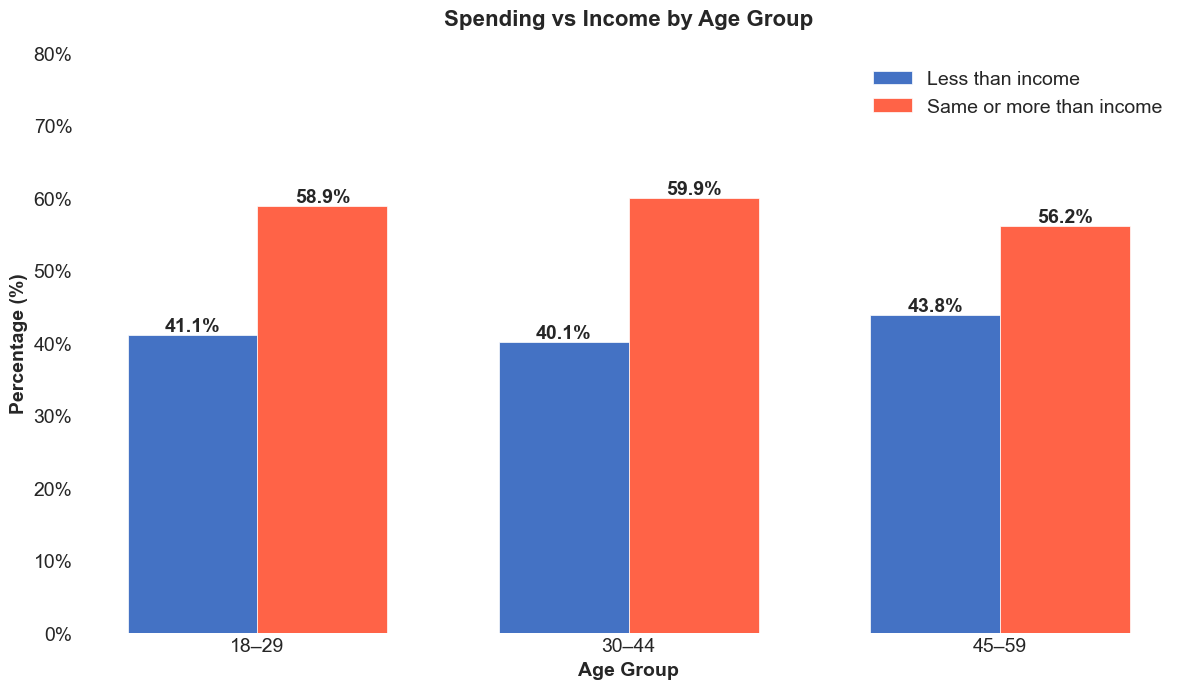


Spending vs Income by Age Group (Ages 18-59):
I20_grouped  Less than your income  Same or more than your income
ppagect4                                                         
18–29                        41.10                          58.90
30–44                        40.10                          59.90
45–59                        43.80                          56.20

Total respondents included: 1,187


In [10]:
# Chart 1: Age Groups vs Spending Behavior (I20)
# Filter for age groups under 55 and valid I20 responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart = df[df['ppagect4'].isin(age_groups_to_include) & df['I20'].notna()].copy()

# Create a new spending category combining "same" and "more"
df_chart['I20_grouped'] = df_chart['I20'].apply(
    lambda x: 'Less than your income' if x == 'Less than your income' else 'Same or more than your income'
)

# Create crosstab with percentages
spending_by_age = pd.crosstab(df_chart['ppagect4'], df_chart['I20_grouped'], normalize='index') * 100

# Ensure the columns are in the desired order
spending_order = ['Less than your income', 'Same or more than your income']
spending_by_age = spending_by_age[spending_order]

# Reindex to ensure age groups are in order
spending_by_age = spending_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.35

# Define simple, distinguishable colors
colors = ['#4472C4', '#FF6347']  # Blue for "Less", Red-orange for "Same or more"

# Create bars for each spending category
bars1 = ax.bar(x - width/2, spending_by_age[spending_order[0]], width, 
               label='Less than income', color=colors[0], edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, spending_by_age[spending_order[1]], width, 
               label='Same or more than income', color=colors[1], edgecolor='white', linewidth=0.5)

# Add percentage labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Spending vs Income by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14)

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-100%
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSpending vs Income by Age Group (Ages 18-59):")
print("="*60)
print(spending_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart):,}")

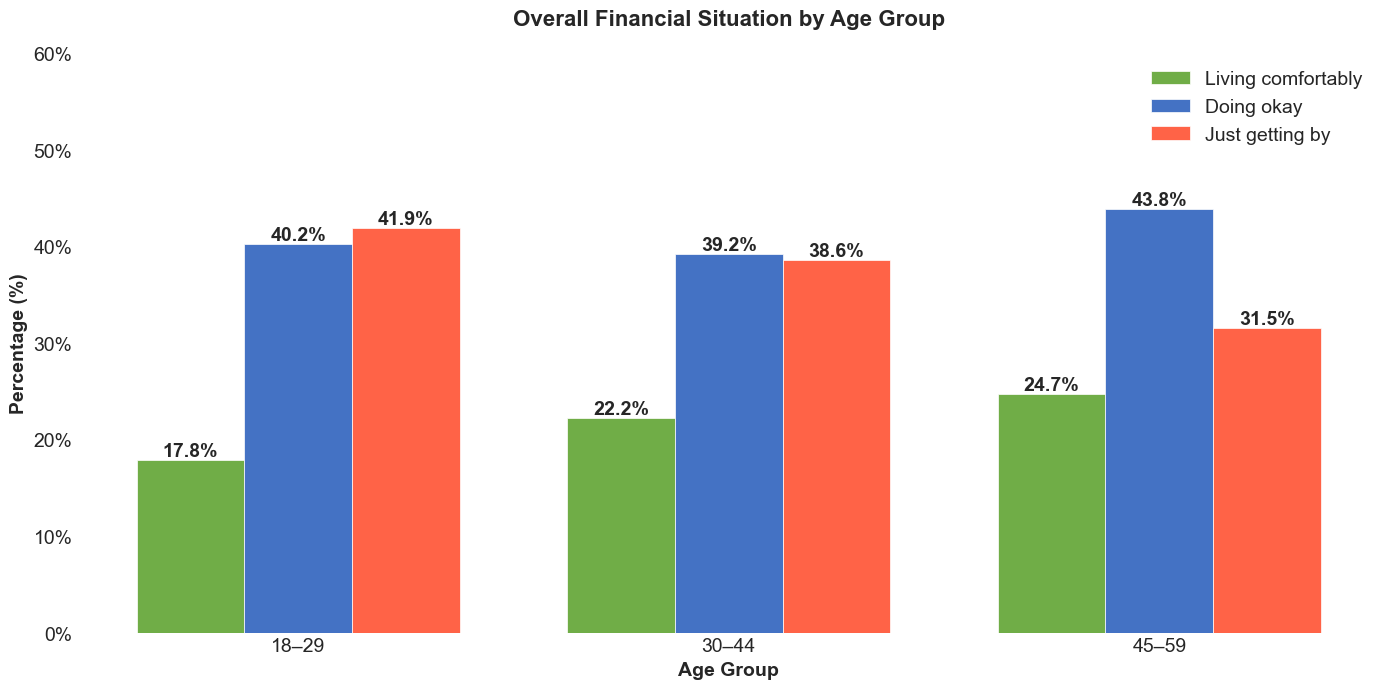


Overall Financial Situation by Age Group (Ages 18-59):
B2_grouped  Living comfortably  Doing okay  Just getting by
ppagect4                                                   
18–29                    17.80       40.20            41.90
30–44                    22.20       39.20            38.60
45–59                    24.70       43.80            31.50

Total respondents included: 1,187


In [11]:
# Chart 2: Age Groups vs Overall Financial Situation (B2)
# Filter for age groups under 55 and valid B2 responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart2 = df[df['ppagect4'].isin(age_groups_to_include) & df['B2'].notna()].copy()

# Create a new B2 category combining "just getting by" and "finding it difficult"
df_chart2['B2_grouped'] = df_chart2['B2'].apply(
    lambda x: 'Just getting by' if x in ['Just getting by', 'Finding it difficult to get by'] 
    else x
)

# Create crosstab with percentages
financial_by_age = pd.crosstab(df_chart2['ppagect4'], df_chart2['B2_grouped'], normalize='index') * 100

# Define the order of financial situation categories (from best to worst)
financial_order = ['Living comfortably', 'Doing okay', 'Just getting by']

# Filter to only include categories that exist in the data
financial_order = [cat for cat in financial_order if cat in financial_by_age.columns]
financial_by_age = financial_by_age[financial_order]

# Reindex to ensure age groups are in order
financial_by_age = financial_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.25

# Define simple, distinguishable colors
colors = ['#70AD47', '#4472C4', '#FF6347']  # Green, Blue, Red-orange

# Create bars for each financial situation category
bars = []
for i, category in enumerate(financial_order):
    offset = (i - len(financial_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, financial_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Overall Financial Situation by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14)

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-60%
ax.set_ylim(0, 60)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nOverall Financial Situation by Age Group (Ages 18-59):")
print("="*60)
print(financial_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart2):,}")

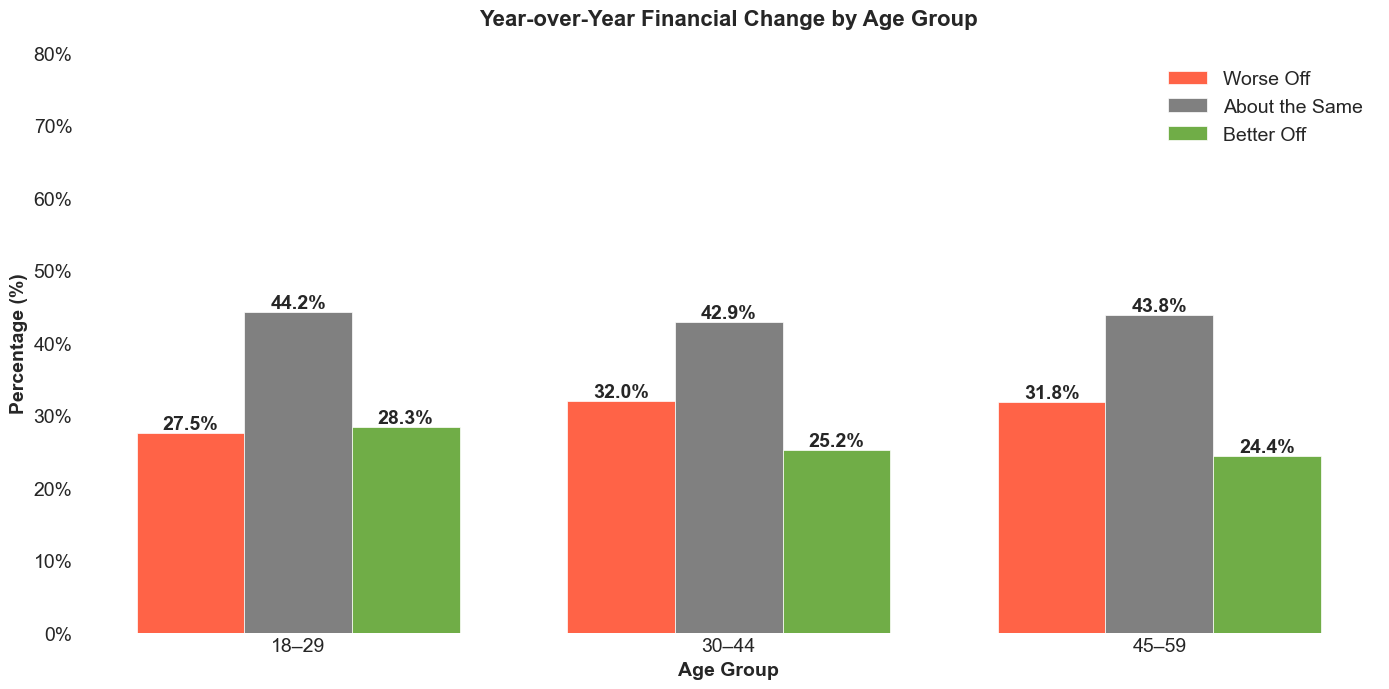


Year-over-Year Financial Change by Age Group (Ages 18-59):
B3_aggregated  Worse Off  About the Same  Better Off
ppagect4                                            
18–29              27.50           44.20       28.30
30–44              32.00           42.90       25.20
45–59              31.80           43.80       24.40

Total respondents included: 1,187


In [12]:
# Chart 2A: Age Groups vs Year-over-Year Financial Change (B3)
# Filter for age groups under 60 and valid B3 responses

# Define age groups to include (excluding 60+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart2a = df[df['ppagect4'].isin(age_groups_to_include) & df['B3'].notna()].copy()

# Aggregate B3 into 3 categories
def aggregate_b3(value):
    if value in ['Much worse off', 'Somewhat worse off']:
        return 'Worse Off'
    elif value == 'About the same':
        return 'About the Same'
    else:  # 'Somewhat better off' or 'Much better off'
        return 'Better Off'

df_chart2a['B3_aggregated'] = df_chart2a['B3'].apply(aggregate_b3)

# Create crosstab with percentages
b3_by_age = pd.crosstab(df_chart2a['ppagect4'], df_chart2a['B3_aggregated'], normalize='index') * 100

# Define the order of B3 categories (from worse to better)
b3_order = ['Worse Off', 'About the Same', 'Better Off']

# Filter to only include categories that exist in the data
b3_order = [cat for cat in b3_order if cat in b3_by_age.columns]
b3_by_age = b3_by_age[b3_order]

# Reindex to ensure age groups are in order
b3_by_age = b3_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.25

# Define simple, distinguishable colors
colors = ['#FF6347', '#808080', '#70AD47']  # Red-orange, Gray, Green

# Create bars for each B3 category
bars = []
for i, category in enumerate(b3_order):
    offset = (i - len(b3_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, b3_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Year-over-Year Financial Change by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14)

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-80%
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nYear-over-Year Financial Change by Age Group (Ages 18-59):")
print("="*60)
print(b3_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart2a):,}")


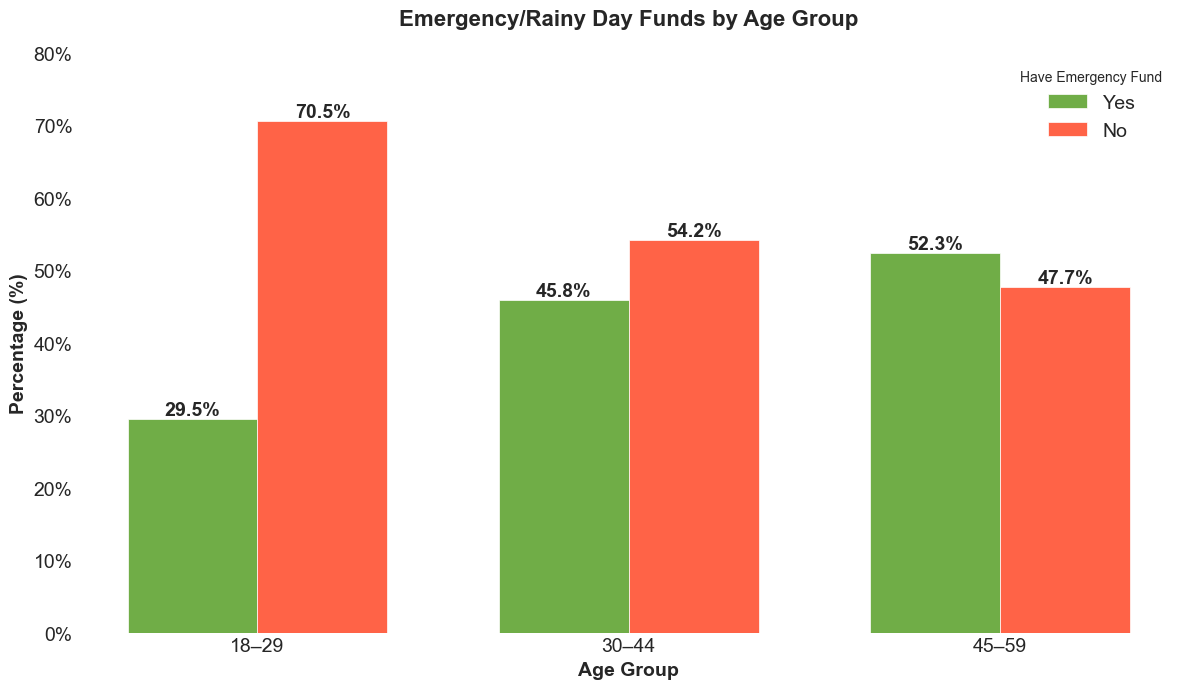


Emergency/Rainy Day Funds by Age Group (Ages 18-59):
EF1        Yes    No
ppagect4            
18–29    29.50 70.50
30–44    45.80 54.20
45–59    52.30 47.70

Total respondents included: 1,187


In [13]:
# Chart 3: Age Groups vs Emergency Savings Fund (EF1)
# Filter for age groups under 55 and valid EF1 responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart3 = df[df['ppagect4'].isin(age_groups_to_include) & df['EF1'].notna()].copy()

# Create crosstab with percentages
ef1_by_age = pd.crosstab(df_chart3['ppagect4'], df_chart3['EF1'], normalize='index') * 100

# Define the order of EF1 categories
ef1_order = ['Yes', 'No']

# Filter to only include categories that exist in the data
ef1_order = [cat for cat in ef1_order if cat in ef1_by_age.columns]
ef1_by_age = ef1_by_age[ef1_order]

# Reindex to ensure age groups are in order
ef1_by_age = ef1_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.35

# Define simple, distinguishable colors
colors = ['#70AD47', '#FF6347']  # Green for "Yes", Red-orange for "No"

# Create bars for each EF1 category
bars = []
for i, category in enumerate(ef1_order):
    offset = (i - len(ef1_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, ef1_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Emergency/Rainy Day Funds by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14, title='Have Emergency Fund')

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-80%
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nEmergency/Rainy Day Funds by Age Group (Ages 18-59):")
print("="*60)
print(ef1_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart3):,}")

/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_21743/3091593904.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart4[df_chart4[var].notna()].groupby('ppagect4').apply(
/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_21743/3091593904.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart4[df_chart4[var].notna()].groupby('ppagect4').apply(
/var/folders/k

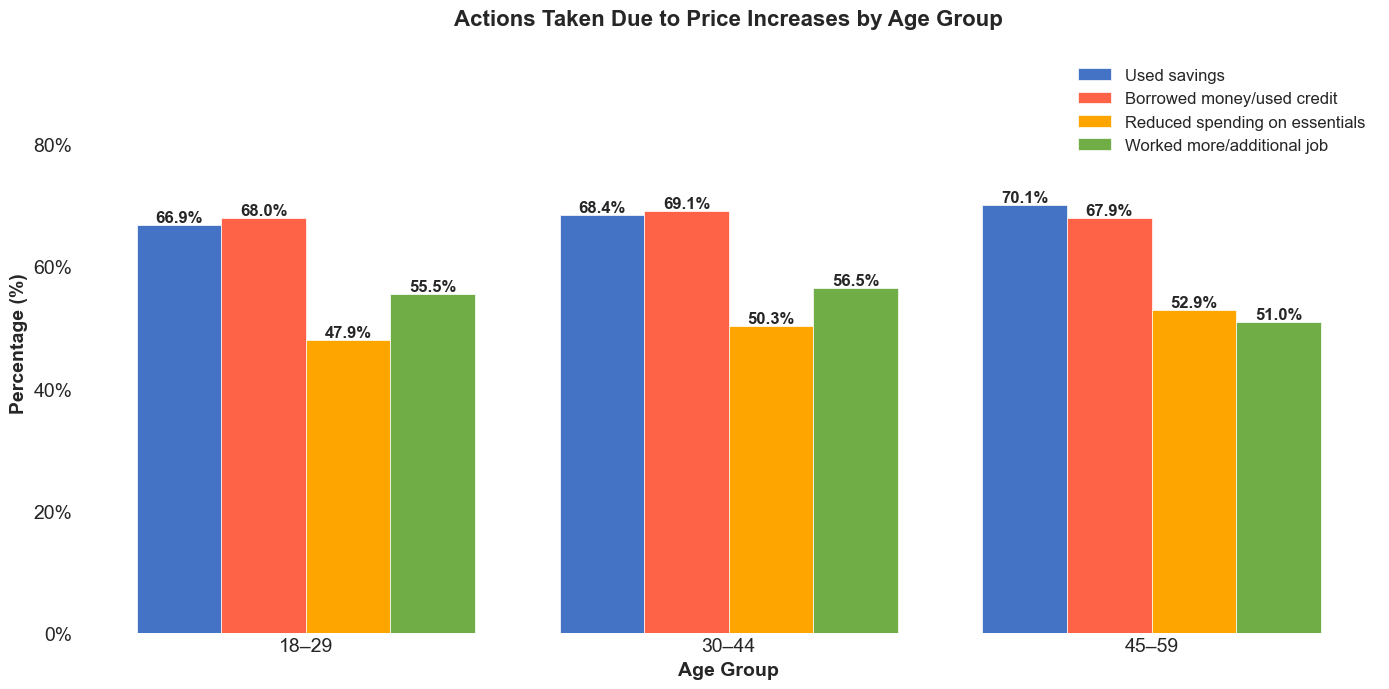


Actions Taken Due to Price Increases by Age Group (Ages 18-59):
          Used savings  Borrowed money/used credit  Reduced spending on essentials  Worked more/additional job
ppagect4                                                                                                      
18–29            66.90                       68.00                           47.90                       55.50
30–44            68.40                       69.10                           50.30                       56.50
45–59            70.10                       67.90                           52.90                       51.00

Total respondents: 1,187


In [14]:
# Chart 4: Age Groups vs Actions Taken Due to Price Increases (INF3 series)
# Filter for age groups under 55 and valid INF3 responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Define the INF3 variables to include
inf3_vars = {
    'INF3_a': 'Used savings',
    'INF3_b': 'Borrowed money/used credit',
    'INF3_c': 'Reduced spending on essentials',
    'INF3_e': 'Worked more/additional job'
}

# Filter data for age groups under 55
df_chart4 = df[df['ppagect4'].isin(age_groups_to_include)].copy()

# Calculate percentages for each action by age group
inf3_by_age = pd.DataFrame()

for var, label in inf3_vars.items():
    if var in df_chart4.columns:
        pct_by_age = df_chart4[df_chart4[var].notna()].groupby('ppagect4').apply(
            lambda x: (x[var] == 'Yes').sum() / len(x) * 100
        )
        inf3_by_age[label] = pct_by_age

# Reindex to ensure age groups are in order
inf3_by_age = inf3_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.2

# Define simple, distinguishable colors
colors = ['#4472C4', '#FF6347', '#FFA500', '#70AD47']  # Blue, Red-orange, Orange, Green

# Create bars for each action category
bars = []
action_labels = list(inf3_vars.values())

for i, action in enumerate(action_labels):
    if action in inf3_by_age.columns:
        offset = (i - len(action_labels)/2 + 0.5) * width
        bar = ax.bar(x + offset, inf3_by_age[action], width, 
                     label=action, color=colors[i], edgecolor='white', linewidth=0.5)
        bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Actions Taken Due to Price Increases by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nActions Taken Due to Price Increases by Age Group (Ages 18-59):")
print("="*60)
print(inf3_by_age.round(1).to_string())
print(f"\nTotal respondents: {len(df_chart4):,}")

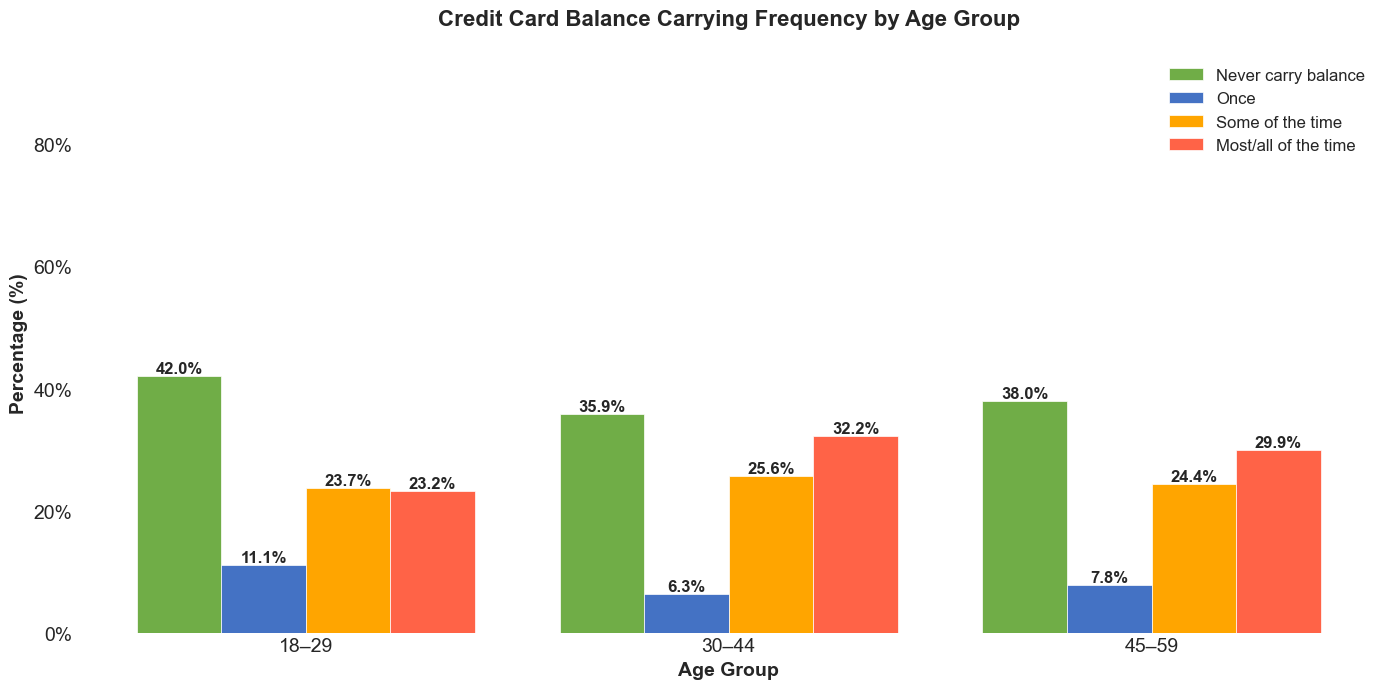


Credit Card Balance Carrying Frequency by Age Group (Ages 18-59):
C4A       Never carried an unpaid balance (always pay in full)  Once  Some of the time  Most or all of the time
ppagect4                                                                                                       
18–29                                                    42.00 11.10             23.70                    23.20
30–44                                                    35.90  6.30             25.60                    32.20
45–59                                                    38.00  7.80             24.40                    29.90

Total respondents included: 866


In [15]:
# Chart 5: Age Groups vs Credit Card Balance Carrying Behavior (C4A)
# Filter for age groups under 55 and valid C4A responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart5 = df[df['ppagect4'].isin(age_groups_to_include) & df['C4A'].notna()].copy()

# Create crosstab with percentages
c4a_by_age = pd.crosstab(df_chart5['ppagect4'], df_chart5['C4A'], normalize='index') * 100

# Define the order of C4A categories (from best to worst)
c4a_order = ['Never carried an unpaid balance (always pay in full)', 
             'Once', 
             'Some of the time', 
             'Most or all of the time']

# Filter to only include categories that exist in the data
c4a_order = [cat for cat in c4a_order if cat in c4a_by_age.columns]
c4a_by_age = c4a_by_age[c4a_order]

# Reindex to ensure age groups are in order
c4a_by_age = c4a_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.2

# Define simple, distinguishable colors
colors = ['#70AD47', '#4472C4', '#FFA500', '#FF6347']  # Green, Blue, Orange, Red-orange

# Create bars for each C4A category
bars = []
# Use shortened labels for the chart
short_labels = ['Never carry balance', 'Once', 'Some of the time', 'Most/all of the time']

for i, category in enumerate(c4a_order):
    offset = (i - len(c4a_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, c4a_by_age[category], width, 
                 label=short_labels[i], color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Credit Card Balance Carrying Frequency by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nCredit Card Balance Carrying Frequency by Age Group (Ages 18-59):")
print("="*60)
print(c4a_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart5):,}")

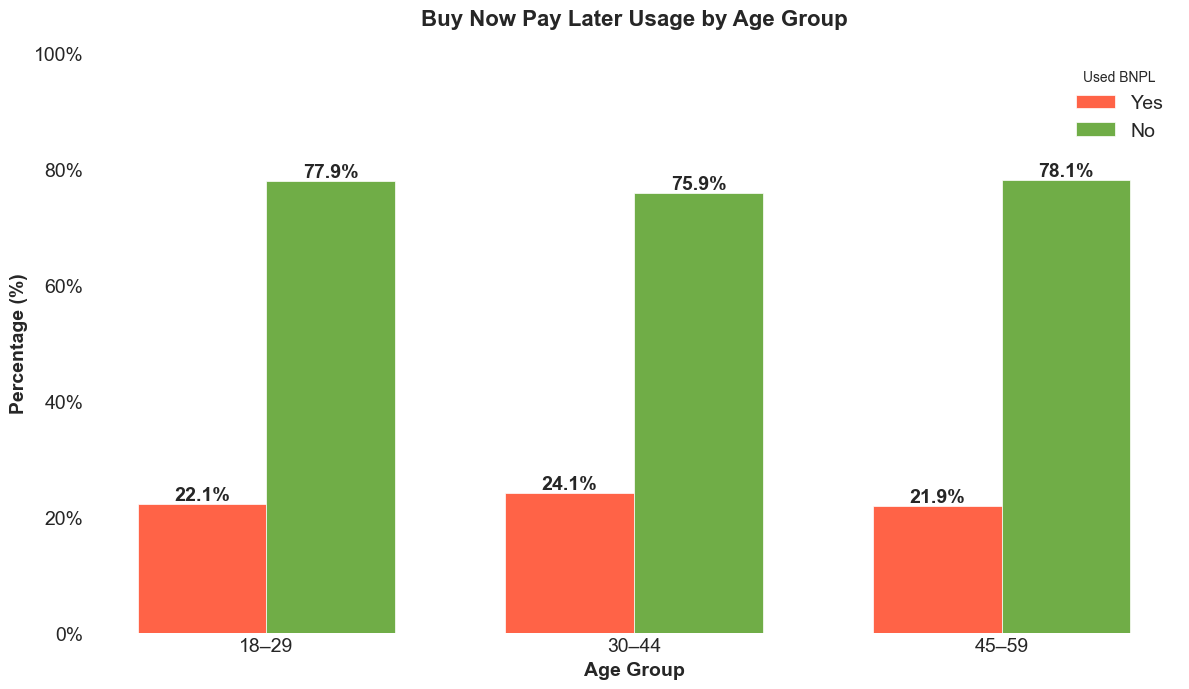


Buy Now Pay Later Usage by Age Group (Ages 18-59):
BNPL1      Yes    No
ppagect4            
18–29    22.10 77.90
30–44    24.10 75.90
45–59    21.90 78.10

Total respondents included: 1,187


In [16]:
# Chart 6: Age Groups vs Buy Now Pay Later Usage (BNPL1)
# Filter for age groups under 55 and valid BNPL1 responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart6 = df[df['ppagect4'].isin(age_groups_to_include) & df['BNPL1'].notna()].copy()

# Create crosstab with percentages
bnpl1_by_age = pd.crosstab(df_chart6['ppagect4'], df_chart6['BNPL1'], normalize='index') * 100

# Define the order of BNPL1 categories
bnpl1_order = ['Yes', 'No']

# Filter to only include categories that exist in the data
bnpl1_order = [cat for cat in bnpl1_order if cat in bnpl1_by_age.columns]
bnpl1_by_age = bnpl1_by_age[bnpl1_order]

# Reindex to ensure age groups are in order
bnpl1_by_age = bnpl1_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.35

# Define simple, distinguishable colors
colors = ['#FF6347', '#70AD47']  # Red-orange for "Yes", Green for "No"

# Create bars for each BNPL1 category
bars = []
for i, category in enumerate(bnpl1_order):
    offset = (i - len(bnpl1_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, bnpl1_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Buy Now Pay Later Usage by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14, title='Used BNPL', bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-100%
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nBuy Now Pay Later Usage by Age Group (Ages 18-59):")
print("="*60)
print(bnpl1_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart6):,}")

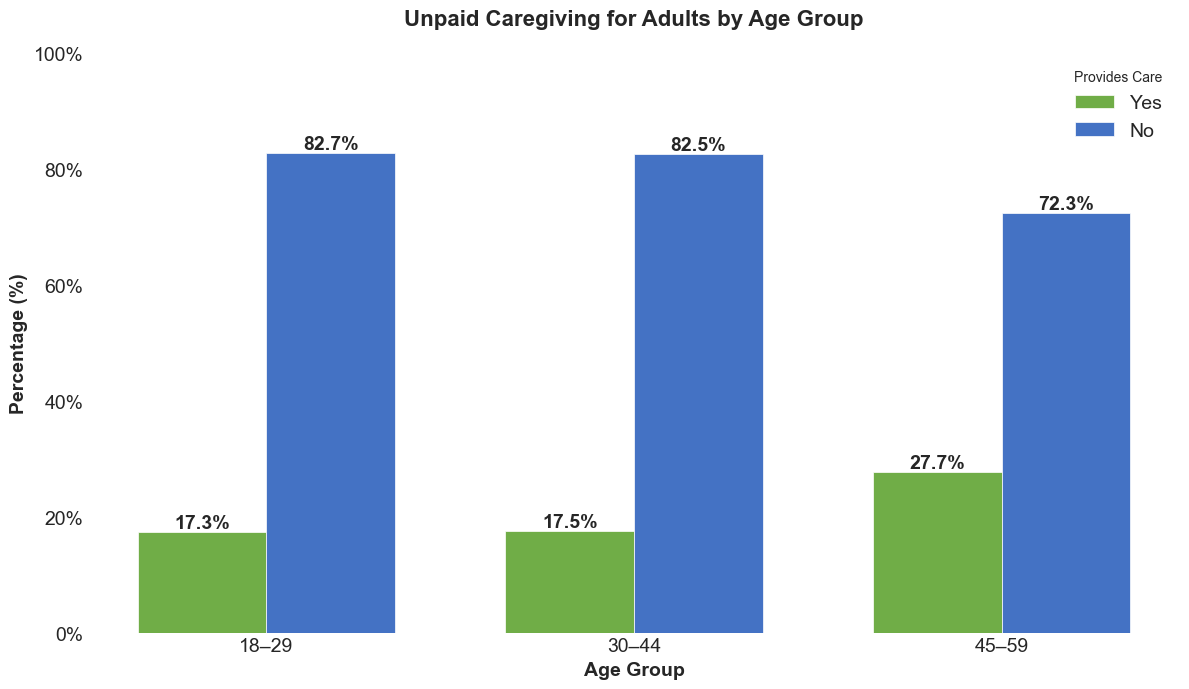


Unpaid Caregiving for Adults by Age Group (Ages 18-59):
CG4        Yes    No
ppagect4            
18–29    17.30 82.70
30–44    17.50 82.50
45–59    27.70 72.30

Total respondents included: 1,187


In [17]:
# Chart 7: Age Groups vs Unpaid Caregiving for Adults (CG4)
# Filter for age groups under 55 and valid CG4 responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart7 = df[df['ppagect4'].isin(age_groups_to_include) & df['CG4'].notna()].copy()

# Create crosstab with percentages
cg4_by_age = pd.crosstab(df_chart7['ppagect4'], df_chart7['CG4'], normalize='index') * 100

# Define the order of CG4 categories
cg4_order = ['Yes', 'No']

# Filter to only include categories that exist in the data
cg4_order = [cat for cat in cg4_order if cat in cg4_by_age.columns]
cg4_by_age = cg4_by_age[cg4_order]

# Reindex to ensure age groups are in order
cg4_by_age = cg4_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.35

# Define simple, distinguishable colors
colors = ['#70AD47', '#4472C4']  # Green for "Yes", Blue for "No"

# Create bars for each CG4 category
bars = []
for i, category in enumerate(cg4_order):
    offset = (i - len(cg4_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, cg4_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Unpaid Caregiving for Adults by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14, title='Provides Care', bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-100%
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nUnpaid Caregiving for Adults by Age Group (Ages 18-59):")
print("="*60)
print(cg4_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart7):,}")

/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_21743/3014409899.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart8[df_chart8[var].notna()].groupby('ppagect4').apply(
/var/folders/kn/k2gq2hds1tg0q3tdmc6sxh4m0000gn/T/ipykernel_21743/3014409899.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_by_age = df_chart8[df_chart8[var].notna()].groupby('ppagect4').apply(
/var/folders/k

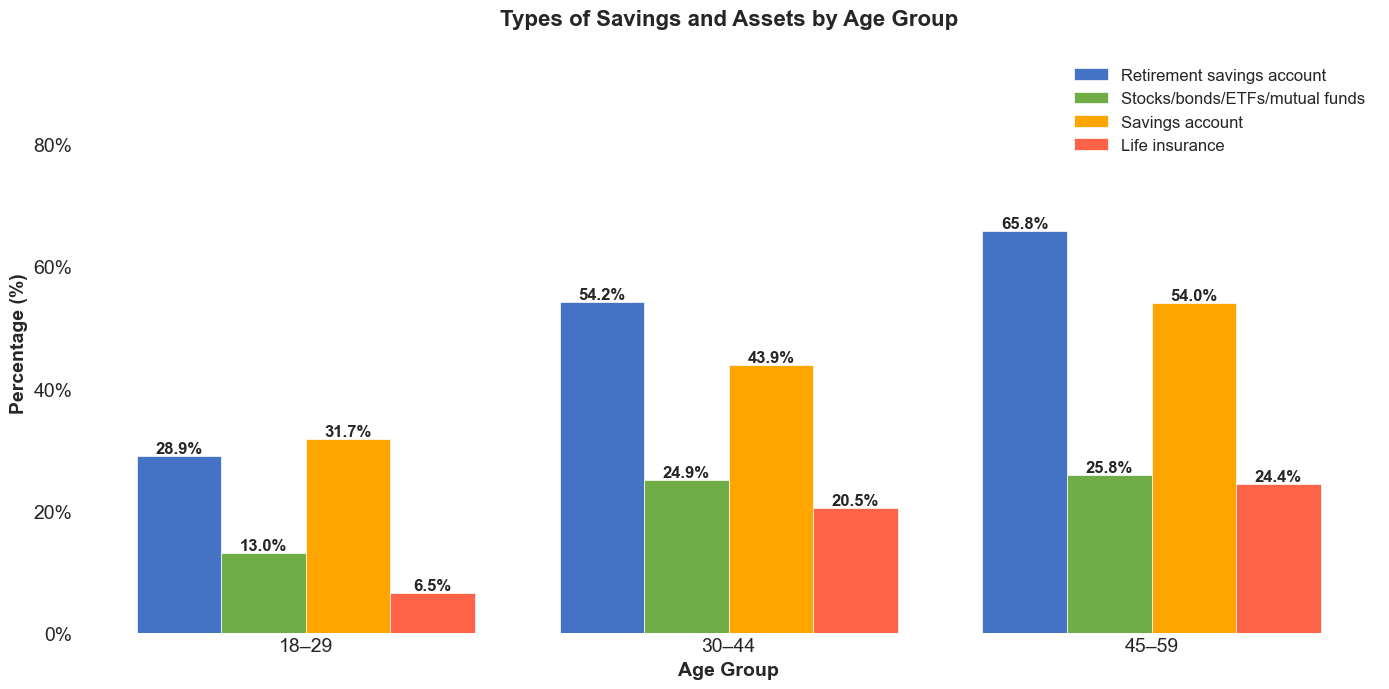


Types of Savings and Assets by Age Group (Ages 18-59):
          Retirement savings account  Stocks/bonds/ETFs/mutual funds  Savings account  Life insurance
ppagect4                                                                                             
18–29                          28.90                           13.00            31.70            6.50
30–44                          54.20                           24.90            43.90           20.50
45–59                          65.80                           25.80            54.00           24.40

Total respondents: 1,187


In [18]:
# Chart 8: Age Groups vs Types of Savings/Assets (K21 series)
# Filter for age groups under 55 and valid K21 responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Define the K21 variables to include
k21_vars = {
    'K21_a': 'Retirement savings account',
    'K21_c': 'Stocks/bonds/ETFs/mutual funds',
    'K21_d': 'Savings account',
    'K21_e': 'Life insurance'
}

# Filter data for age groups under 55
df_chart8 = df[df['ppagect4'].isin(age_groups_to_include)].copy()

# Calculate percentages for each asset type by age group
k21_by_age = pd.DataFrame()

for var, label in k21_vars.items():
    if var in df_chart8.columns:
        pct_by_age = df_chart8[df_chart8[var].notna()].groupby('ppagect4').apply(
            lambda x: (x[var] == 'Yes').sum() / len(x) * 100
        )
        k21_by_age[label] = pct_by_age

# Reindex to ensure age groups are in order
k21_by_age = k21_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.2

# Define simple, distinguishable colors
colors = ['#4472C4', '#70AD47', '#FFA500', '#FF6347']  # Blue, Green, Orange, Red-orange

# Create bars for each asset category
bars = []
asset_labels = list(k21_vars.values())

for i, asset in enumerate(asset_labels):
    if asset in k21_by_age.columns:
        offset = (i - len(asset_labels)/2 + 0.5) * width
        bar = ax.bar(x + offset, k21_by_age[asset], width, 
                     label=asset, color=colors[i], edgecolor='white', linewidth=0.5)
        bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Types of Savings and Assets by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nTypes of Savings and Assets by Age Group (Ages 18-59):")
print("="*60)
print(k21_by_age.round(1).to_string())
print(f"\nTotal respondents: {len(df_chart8):,}")

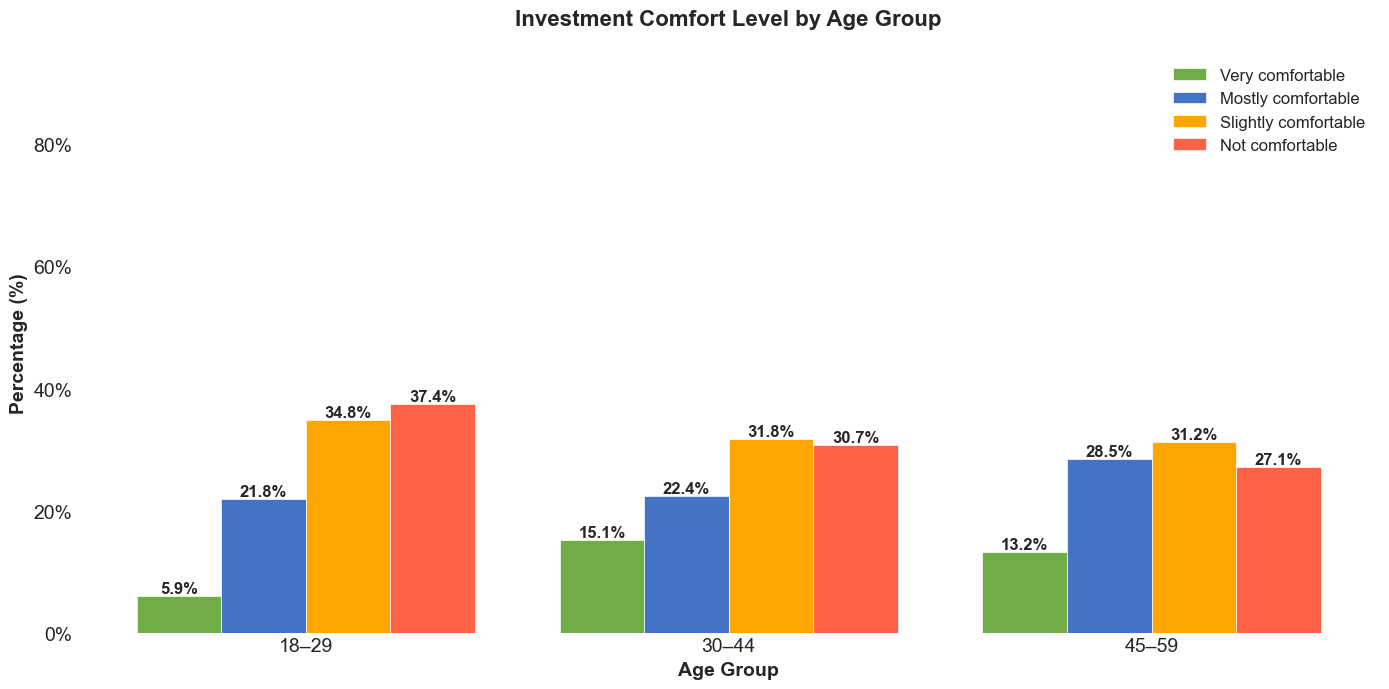


Investment Comfort Level by Age Group (Ages 18-59):
DC4       Very comfortable  Mostly comfortable  Slightly comfortable  Not comfortable
ppagect4                                                                             
18–29                 5.90               21.80                 34.80            37.40
30–44                15.10               22.40                 31.80            30.70
45–59                13.20               28.50                 31.20            27.10

Total respondents included: 1,187


In [19]:
# Chart 9: Age Groups vs Investment Comfort Level (DC4)
# Filter for age groups under 55 and valid DC4 responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart9 = df[df['ppagect4'].isin(age_groups_to_include) & df['DC4'].notna()].copy()

# Create crosstab with percentages
dc4_by_age = pd.crosstab(df_chart9['ppagect4'], df_chart9['DC4'], normalize='index') * 100

# Define the order of DC4 categories (from most to least comfortable)
dc4_order = ['Very comfortable', 'Mostly comfortable', 'Slightly comfortable', 'Not comfortable']

# Filter to only include categories that exist in the data
dc4_order = [cat for cat in dc4_order if cat in dc4_by_age.columns]
dc4_by_age = dc4_by_age[dc4_order]

# Reindex to ensure age groups are in order
dc4_by_age = dc4_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.2

# Define simple, distinguishable colors
colors = ['#70AD47', '#4472C4', '#FFA500', '#FF6347']  # Green, Blue, Orange, Red-orange

# Create bars for each DC4 category
bars = []
for i, category in enumerate(dc4_order):
    offset = (i - len(dc4_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, dc4_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Investment Comfort Level by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nInvestment Comfort Level by Age Group (Ages 18-59):")
print("="*60)
print(dc4_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart9):,}")

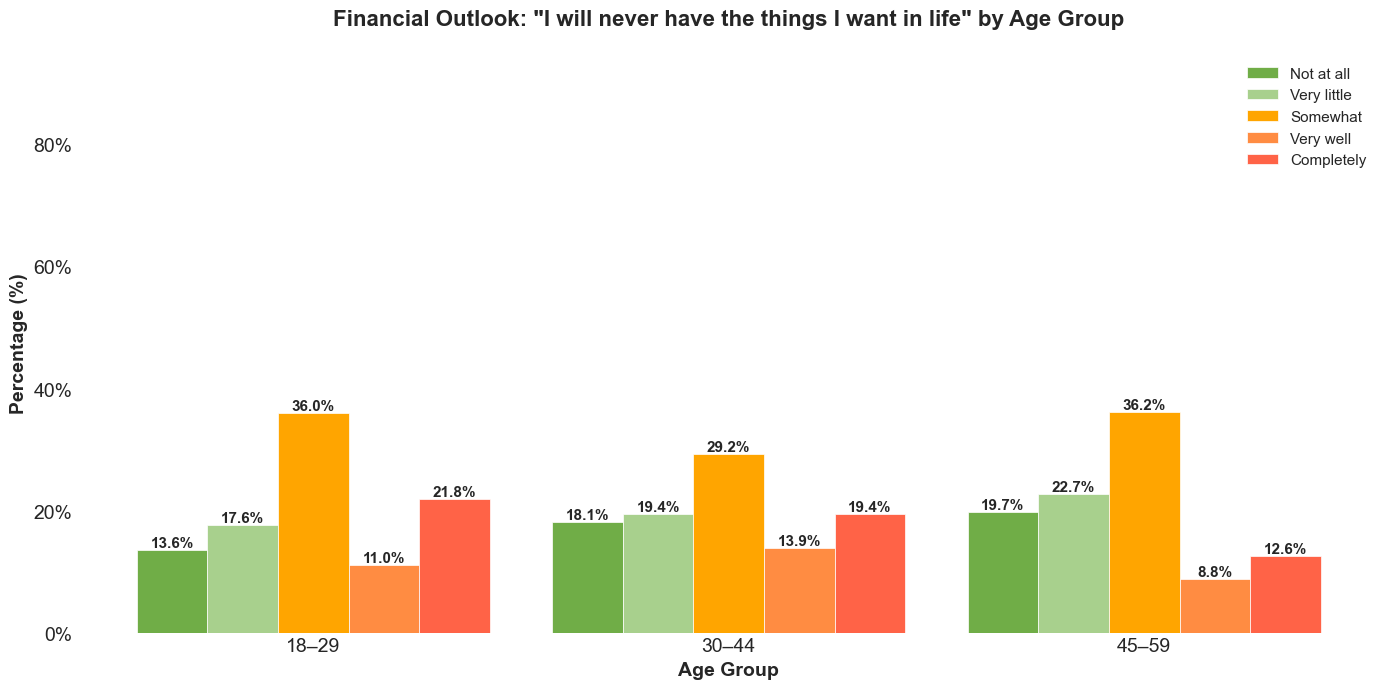


Financial Outlook by Age Group (Ages 18-59):
B0_a      Not at all  Very little  Somewhat  Very well  Completely
ppagect4                                                          
18–29          13.60        17.60     36.00      11.00       21.80
30–44          18.10        19.40     29.20      13.90       19.40
45–59          19.70        22.70     36.20       8.80       12.60

Total respondents included: 1,187


In [20]:
# Chart 10: Age Groups vs Financial Outlook (B0_a)
# Filter for age groups under 55 and valid B0_a responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart10 = df[df['ppagect4'].isin(age_groups_to_include) & df['B0_a'].notna()].copy()

# Create crosstab with percentages
b0a_by_age = pd.crosstab(df_chart10['ppagect4'], df_chart10['B0_a'], normalize='index') * 100

# Define the order of B0_a categories (from most positive to most negative)
b0a_order = ['Not at all', 'Very little', 'Somewhat', 'Very well', 'Completely']

# Filter to only include categories that exist in the data
b0a_order = [cat for cat in b0a_order if cat in b0a_by_age.columns]
b0a_by_age = b0a_by_age[b0a_order]

# Reindex to ensure age groups are in order
b0a_by_age = b0a_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.17

# Define simple, distinguishable colors (green for positive, red-orange for negative)
colors = ['#70AD47', '#A8D08D', '#FFA500', '#FF8C42', '#FF6347']

# Create bars for each B0_a category
bars = []
for i, category in enumerate(b0a_order):
    offset = (i - len(b0a_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, b0a_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Financial Outlook: "I will never have the things I want in life" by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=11, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFinancial Outlook by Age Group (Ages 18-59):")
print("="*60)
print(b0a_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart10):,}")

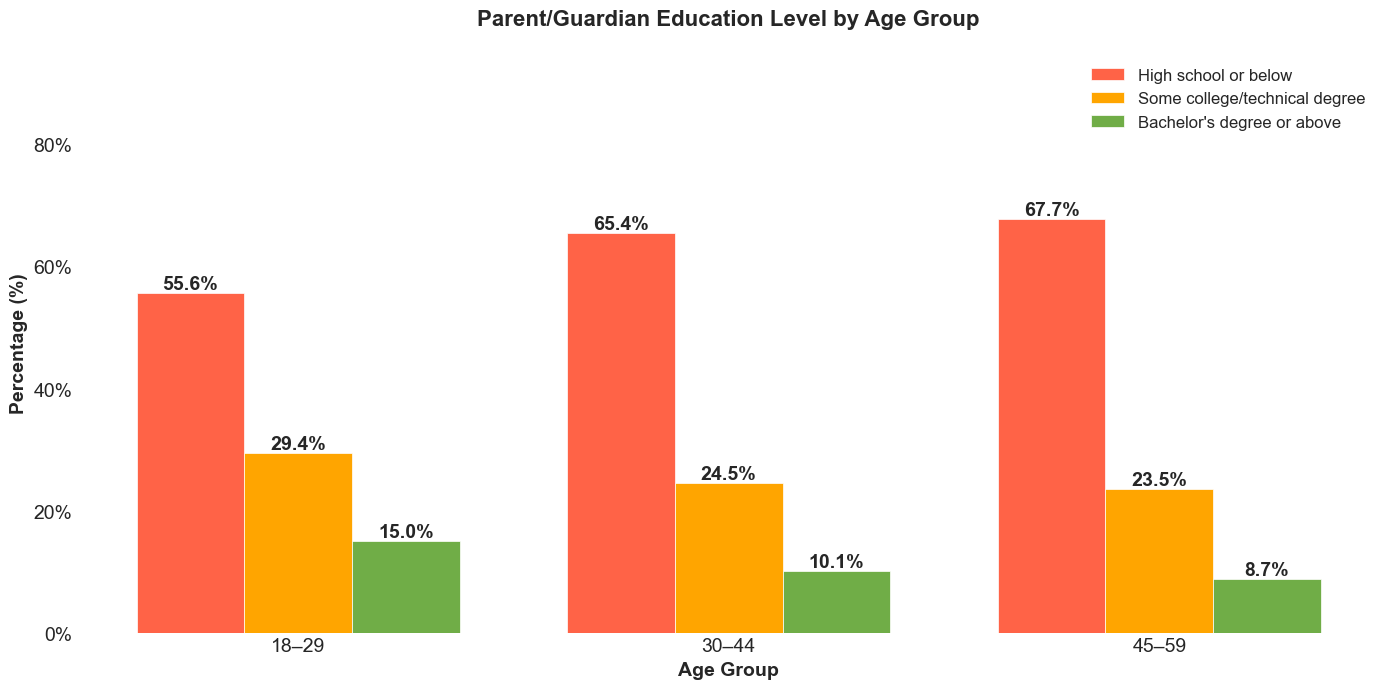


Parent/Guardian Education Level by Age Group (Ages 18-59):
CH2A_grouped  High school or below  Some college/technical degree  Bachelor's degree or above
ppagect4                                                                                     
18–29                        55.60                          29.40                       15.00
30–44                        65.40                          24.50                       10.10
45–59                        67.70                          23.50                        8.70

Total respondents included: 972


In [21]:
# Chart 11: Age Groups vs Parent/Guardian Education Level (CH2A)
# Filter for age groups under 55 and valid CH2A responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart11 = df[df['ppagect4'].isin(age_groups_to_include) & df['CH2A'].notna()].copy()

# Create education categories based on the CH2A codes
def categorize_parent_education(value):
    if value in ['Less than high school degree', 'High school degree or GED']:
        return 'High school or below'
    elif value in ['Some college but no degree', 'Certificate or technical degree', 'Associate degree']:
        return 'Some college/technical degree'
    elif value in ["Bachelor's degree", 'Graduate degree']:
        return "Bachelor's degree or above"
    else:
        return None  # Exclude Don't know, Refused, and blanks

df_chart11['CH2A_grouped'] = df_chart11['CH2A'].apply(categorize_parent_education)

# Filter out None values (Don't know, Refused, blanks)
df_chart11 = df_chart11[df_chart11['CH2A_grouped'].notna()].copy()

# Create crosstab with percentages
ch2a_by_age = pd.crosstab(df_chart11['ppagect4'], df_chart11['CH2A_grouped'], normalize='index') * 100

# Define the order of CH2A categories (from lowest to highest education)
ch2a_order = ['High school or below', 'Some college/technical degree', "Bachelor's degree or above"]

# Filter to only include categories that exist in the data
ch2a_order = [cat for cat in ch2a_order if cat in ch2a_by_age.columns]
ch2a_by_age = ch2a_by_age[ch2a_order]

# Reindex to ensure age groups are in order
ch2a_by_age = ch2a_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.25

# Define simple, distinguishable colors
colors = ['#FF6347', '#FFA500', '#70AD47']  # Red-orange, Orange, Green

# Create bars for each education category
bars = []
for i, category in enumerate(ch2a_order):
    offset = (i - len(ch2a_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, ch2a_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Parent/Guardian Education Level by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nParent/Guardian Education Level by Age Group (Ages 18-59):")
print("="*60)
print(ch2a_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart11):,}")

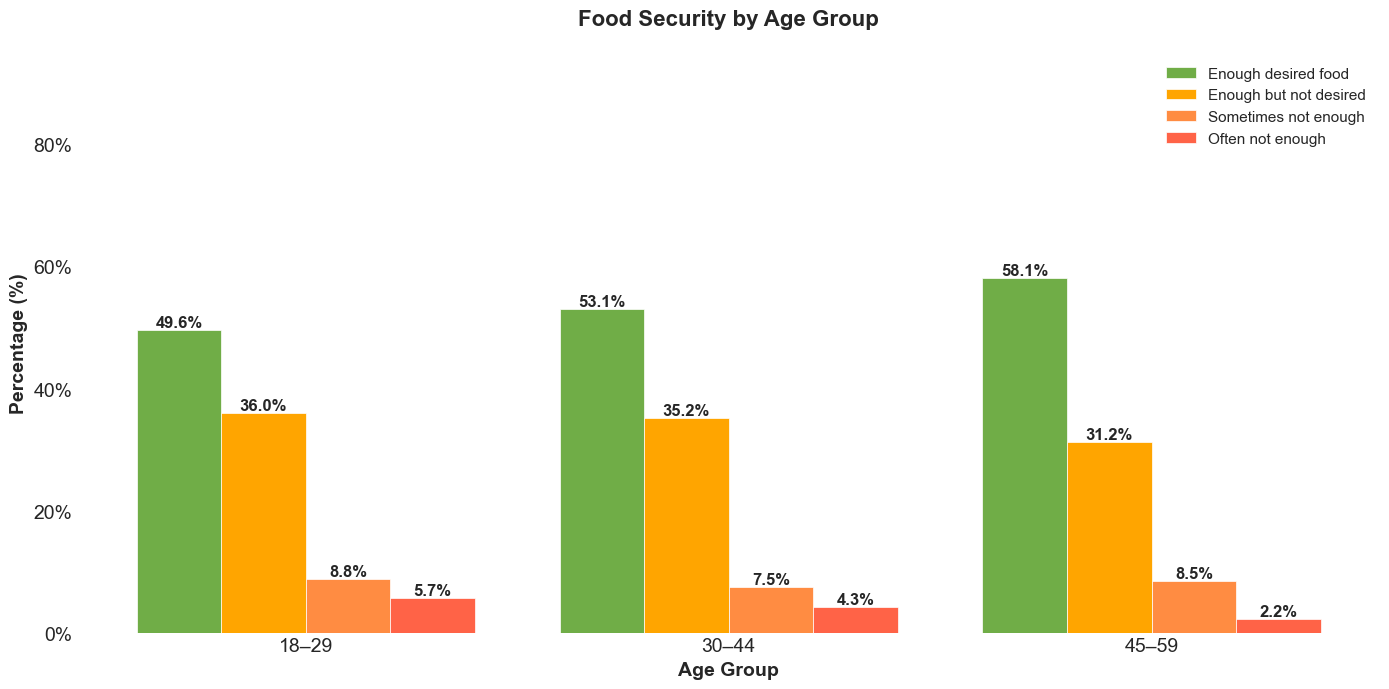


Food Security by Age Group (Ages 18-59):
FD3       Enough of the kinds of food we wanted to eat  Enough, but not always the kinds of food we wanted to eat  Sometimes not enough to eat  Often not enough to eat
ppagect4                                                                                                                                                               
18–29                                            49.60                                                      36.00                         8.80                     5.70
30–44                                            53.10                                                      35.20                         7.50                     4.30
45–59                                            58.10                                                      31.20                         8.50                     2.20

Total respondents included: 1,187


In [22]:
# Chart 12: Age Groups vs Food Security (FD3)
# Filter for age groups under 55 and valid FD3 responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart12 = df[df['ppagect4'].isin(age_groups_to_include) & df['FD3'].notna()].copy()

# Create crosstab with percentages
fd3_by_age = pd.crosstab(df_chart12['ppagect4'], df_chart12['FD3'], normalize='index') * 100

# Define the order of FD3 categories (from best to worst food security)
fd3_order = ['Enough of the kinds of food we wanted to eat', 
             'Enough, but not always the kinds of food we wanted to eat',
             'Sometimes not enough to eat',
             'Often not enough to eat']

# Filter to only include categories that exist in the data
fd3_order = [cat for cat in fd3_order if cat in fd3_by_age.columns]
fd3_by_age = fd3_by_age[fd3_order]

# Reindex to ensure age groups are in order
fd3_by_age = fd3_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.2

# Define simple, distinguishable colors (green for secure, red-orange for insecure)
colors = ['#70AD47', '#FFA500', '#FF8C42', '#FF6347']  # Green, Orange, Light red-orange, Red-orange

# Create bars for each FD3 category
bars = []
# Use shortened labels for better display
short_labels = ['Enough desired food', 'Enough but not desired', 'Sometimes not enough', 'Often not enough']

for i, category in enumerate(fd3_order):
    offset = (i - len(fd3_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, fd3_by_age[category], width, 
                 label=short_labels[i], color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Food Security by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=11, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFood Security by Age Group (Ages 18-59):")
print("="*60)
print(fd3_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart12):,}")

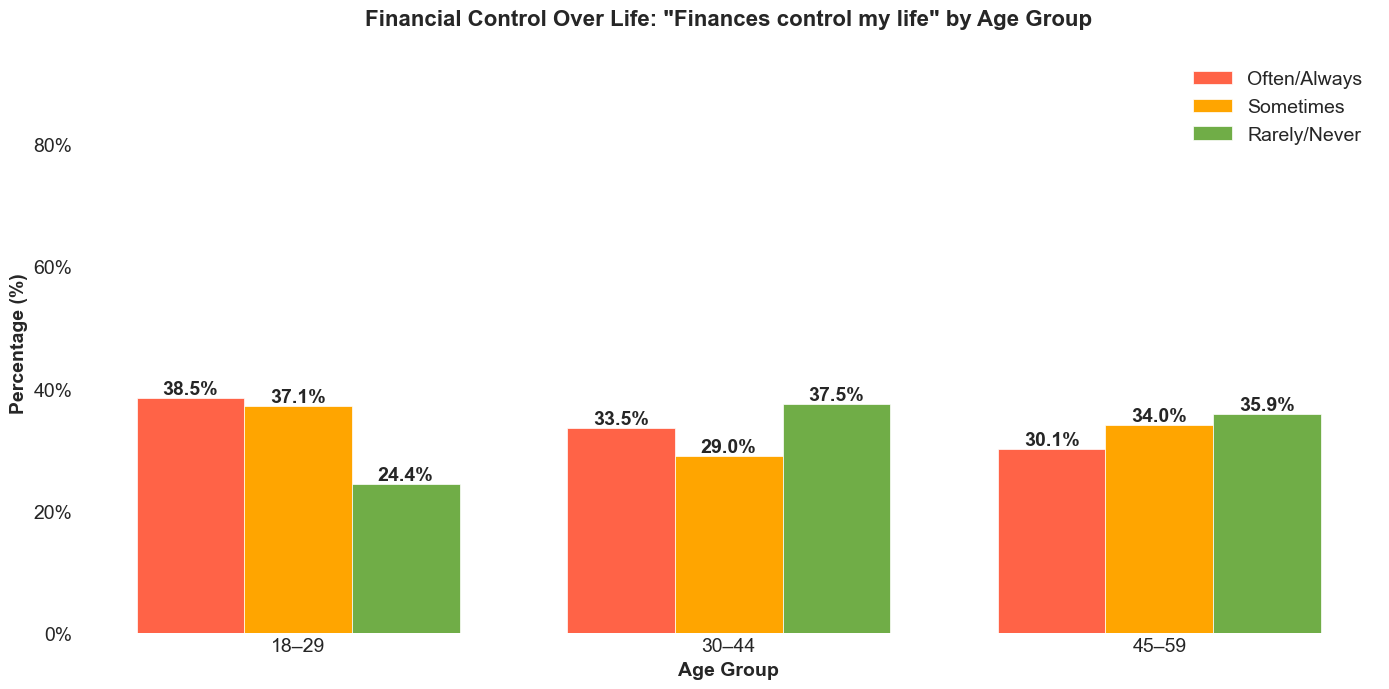


Financial Control Over Life by Age Group (Ages 18-59):
B1_b_grouped  Often/Always  Sometimes  Rarely/Never
ppagect4                                           
18–29                38.50      37.10         24.40
30–44                33.50      29.00         37.50
45–59                30.10      34.00         35.90

Total respondents included: 1,187


In [23]:
# Chart 13: Age Groups vs Financial Control Over Life (B1_b)
# Filter for age groups under 55 and valid B1_b responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart13 = df[df['ppagect4'].isin(age_groups_to_include) & df['B1_b'].notna()].copy()

# Create combined categories
def categorize_financial_control(value):
    if value in ['Always', 'Often']:
        return 'Often/Always'
    elif value == 'Sometimes':
        return 'Sometimes'
    elif value in ['Rarely', 'Never']:
        return 'Rarely/Never'
    else:
        return None

df_chart13['B1_b_grouped'] = df_chart13['B1_b'].apply(categorize_financial_control)

# Filter out None values
df_chart13 = df_chart13[df_chart13['B1_b_grouped'].notna()].copy()

# Create crosstab with percentages
b1b_by_age = pd.crosstab(df_chart13['ppagect4'], df_chart13['B1_b_grouped'], normalize='index') * 100

# Define the order of B1_b categories (from most to least stressed)
b1b_order = ['Often/Always', 'Sometimes', 'Rarely/Never']

# Filter to only include categories that exist in the data
b1b_order = [cat for cat in b1b_order if cat in b1b_by_age.columns]
b1b_by_age = b1b_by_age[b1b_order]

# Reindex to ensure age groups are in order
b1b_by_age = b1b_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.25

# Define simple, distinguishable colors (red-orange for high stress, green for low stress)
colors = ['#FF6347', '#FFA500', '#70AD47']  # Red-orange, Orange, Green

# Create bars for each B1_b category
bars = []
for i, category in enumerate(b1b_order):
    offset = (i - len(b1b_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, b1b_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Financial Control Over Life: "Finances control my life" by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=14, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFinancial Control Over Life by Age Group (Ages 18-59):")
print("="*60)
print(b1b_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart13):,}")

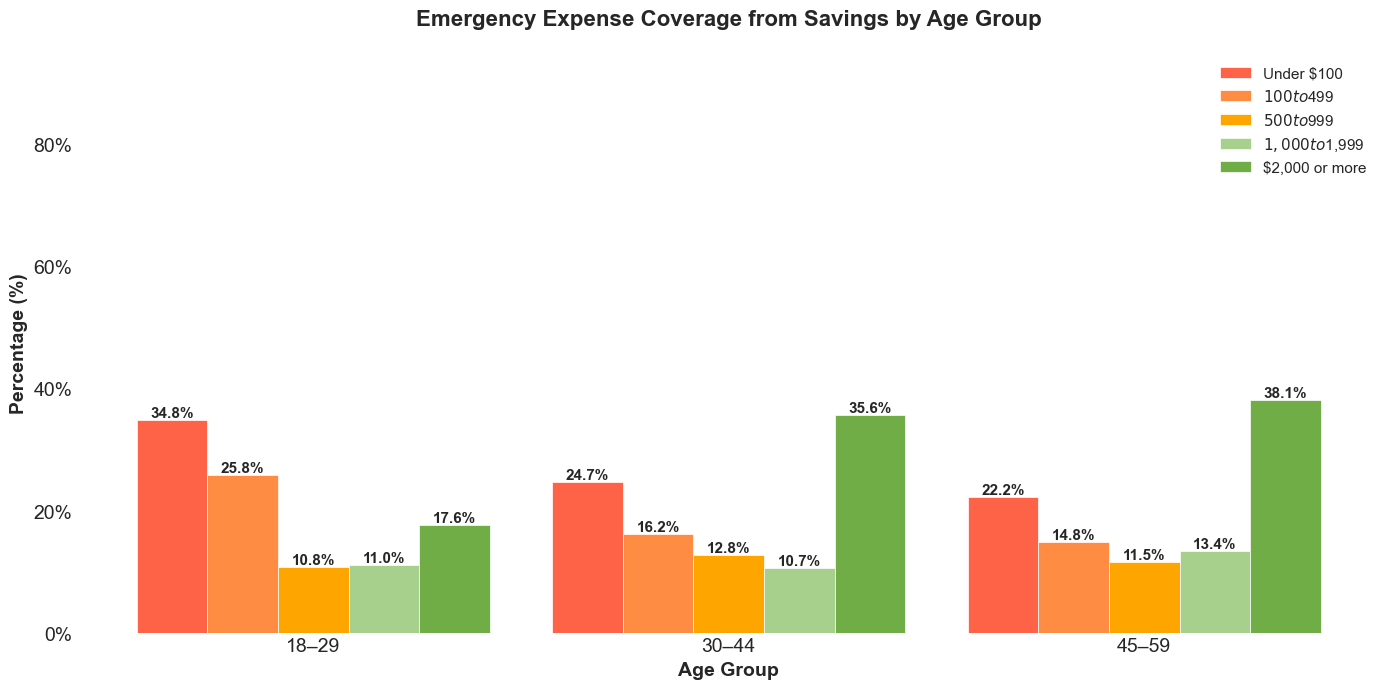


Emergency Expense Coverage from Savings by Age Group (Ages 18-59):
EF7       Under $100  $100 to $499  $500 to $999  $1,000 to $1,999  $2,000 or more
ppagect4                                                                          
18–29          34.80         25.80         10.80             11.00           17.60
30–44          24.70         16.20         12.80             10.70           35.60
45–59          22.20         14.80         11.50             13.40           38.10

Total respondents included: 1,187


In [24]:
# Chart 14: Age Groups vs Emergency Expense Coverage (EF7)
# Filter for age groups under 55 and valid EF7 responses

# Define age groups to include (excluding 55+)
age_groups_to_include = ['18–29', '30–44', '45–59']

# Filter data
df_chart14 = df[df['ppagect4'].isin(age_groups_to_include) & df['EF7'].notna()].copy()

# Create crosstab with percentages
ef7_by_age = pd.crosstab(df_chart14['ppagect4'], df_chart14['EF7'], normalize='index') * 100

# Define the order of EF7 categories (from lowest to highest coverage)
ef7_order = ['Under $100', '$100 to $499', '$500 to $999', '$1,000 to $1,999', '$2,000 or more']

# Filter to only include categories that exist in the data
ef7_order = [cat for cat in ef7_order if cat in ef7_by_age.columns]
ef7_by_age = ef7_by_age[ef7_order]

# Reindex to ensure age groups are in order
ef7_by_age = ef7_by_age.reindex(age_groups_to_include)

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Define bar positions
x = np.arange(len(age_groups_to_include))
width = 0.17

# Define simple, distinguishable colors (red-orange for low, green for high)
colors = ['#FF6347', '#FF8C42', '#FFA500', '#A8D08D', '#70AD47']

# Create bars for each EF7 category
bars = []
for i, category in enumerate(ef7_order):
    offset = (i - len(ef7_order)/2 + 0.5) * width
    bar = ax.bar(x + offset, ef7_by_age[category], width, 
                 label=category, color=colors[i], edgecolor='white', linewidth=0.5)
    bars.append(bar)

# Add percentage labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the chart
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Emergency Expense Coverage from Savings by Age Group', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(age_groups_to_include, fontsize=14)
ax.legend(loc='upper right', frameon=False, fontsize=11, bbox_to_anchor=(1.0, 1.0))

# Remove gridlines and spines for minimalistic look
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Set y-axis to show 0-95%
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nEmergency Expense Coverage from Savings by Age Group (Ages 18-59):")
print("="*60)
print(ef7_by_age.round(1).to_string())
print(f"\nTotal respondents included: {len(df_chart14):,}")